In [1]:
import spikeinterface.full as si
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
spikeglx_folder = Path(r'C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0')
base_folder     = Path(r'C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\standalone_output')
base_folder.mkdir(parents=True, exist_ok=True)

_source_path = str(spikeglx_folder)

In [3]:
# ── FORMAT & SORTER ──────────────────────────────────────────────────────────
FORMAT = 'spikeglx'
sorter = 'kilosort4'

# ── TEST CLIP ────────────────────────────────────────────────────────────────
# Set to a number (e.g. 600) to clip to N seconds for testing; None = full recording
test_duration_s = 60

# ── JOB CONFIG ───────────────────────────────────────────────────────────────
job_kwargs = dict(n_jobs=4, chunk_duration='1s', progress_bar=True)

# ── CHANNEL HANDLING ─────────────────────────────────────────────────────────
# manual_channel_ids: list of channel IDs to keep; None -> keep all
manual_channel_ids    = None
extra_bad_channel_ids = []

# ── ARTIFACT REMOVAL ─────────────────────────────────────────────────────────
artifact_timestamps_s = []   # list of timestamps (s) to blank; [] -> skip
artifact_ms_before    = 2.0
artifact_ms_after     = 5.0

# ── WAVEFORM EXTRACTION ──────────────────────────────────────────────────────
waveform_ms_before  = 1.5
waveform_ms_after   = 2.0
max_spikes_per_unit = 500

# ── QUALITY METRICS ──────────────────────────────────────────────────────────
metric_names = ['firing_rate', 'presence_ratio', 'snr', 'isi_violation', 'amplitude_cutoff']

# ── QUALITY FILTERING ────────────────────────────────────────────────────────
amplitude_cutoff_thresh     = 0.1
isi_violations_ratio_thresh = 1
presence_ratio_thresh       = 0.9

In [4]:
# ── SPIKEGLX-SPECIFIC ────────────────────────────────────────────────────────
stream_name = 'imec0.ap'
freq_min    = 400.   # highpass cutoff (Hz), standard for Neuropixels

cref_operator  = 'median'
cref_reference = 'global'

# Fallback linear probe pitch (um) if no geometry in file
contact_pitch_um = 20.0

_analyzer_sparse = True

In [5]:
# LOAD
raw_rec = si.read_spikeglx(spikeglx_folder, stream_name=stream_name, load_sync_channel=False)

if test_duration_s is not None:
    raw_rec = raw_rec.frame_slice(0, int(test_duration_s * raw_rec.get_sampling_frequency()))
    print(f'[test clip] Truncated to {test_duration_s} s')

print(raw_rec)

[test clip] Truncated to 60 s
FrameSliceRecording: 384 channels - 30000.415126 Hz - 1 segments - 1,800,024 samples - 60.00s 
                     int16 dtype - 1.29 GiB


[probe] Geometry already present — 384 ch, using as-is.


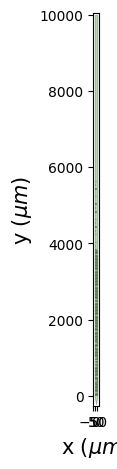

In [6]:
# PROBE SETUP
# contact_pitch_um presets:
#   20 um — Neuropixels 1.0 inner column
#   25 um — Neuropixels 2.0
#   50 um — Cambridge Neurotech H-series
#  100 um — generic low-density silicon probe

if raw_rec.get_property("contact_vector") is None:
    from probeinterface import Probe

    n = raw_rec.get_num_channels()
    probe = Probe(ndim=2, si_units="um")
    probe.set_contacts(
        positions    = np.column_stack([np.zeros(n), np.arange(n, dtype=float) * contact_pitch_um]),
        shapes       = "circle",
        shape_params = {"radius": min(contact_pitch_um * 0.35, 7.5)},
    )
    probe.create_auto_shape(probe_type="tip")
    probe.set_device_channel_indices(np.arange(n))
    raw_rec = raw_rec.set_probe(probe, group_mode="by_probe")
    print(f"[probe] Fallback linear probe — {n} ch | {contact_pitch_um} um pitch | {(n-1)*contact_pitch_um:.0f} um span")
else:
    print(f"[probe] Geometry already present — {raw_rec.get_num_channels()} ch, using as-is.")

si.plot_probe_map(raw_rec, with_channel_ids=False)
plt.tight_layout()
plt.show()

In [7]:
# PREPROCESSING
_n_raw_channels = raw_rec.get_num_channels()

if manual_channel_ids is not None:
    raw_rec = raw_rec.channel_slice(manual_channel_ids)
    print(f"Manual selection: kept {len(manual_channel_ids)} channels")

rec1 = si.phase_shift(raw_rec)
rec1 = si.highpass_filter(rec1, freq_min=freq_min)

if artifact_timestamps_s:
    _fs       = raw_rec.get_sampling_frequency()
    _triggers = [np.array([int(t * _fs) for t in artifact_timestamps_s], dtype=np.int64)]
    rec1 = si.remove_artifacts(rec1, list_triggers=_triggers,
                                ms_before=artifact_ms_before, ms_after=artifact_ms_after,
                                mode='zeros')
    print(f"Artifact removal: blanked {len(artifact_timestamps_s)} event(s)")

bad_channel_ids, channel_labels = si.detect_bad_channels(rec1)

if extra_bad_channel_ids:
    bad_channel_ids = list(set(bad_channel_ids.tolist()) | set(extra_bad_channel_ids))

rec2 = rec1.remove_channels(bad_channel_ids)
rec3 = si.phase_shift(rec2)
rec  = si.common_reference(rec3, operator=cref_operator, reference=cref_reference)
print(rec)

_bad_labels = []
for _ch in bad_channel_ids:
    _idx = np.where(rec1.channel_ids == _ch)[0]
    _bad_labels.append(str(channel_labels[_idx[0]]) if len(_idx) > 0 else 'manual')
with open(base_folder / 'bad_channels.csv', 'w') as _f:
    _f.write('channel_id,label\n')
    for _c, _l in zip(bad_channel_ids, _bad_labels):
        _f.write(f'{_c},{_l}\n')
print(f'Bad channels ({len(bad_channel_ids)}) saved -> {base_folder / "bad_channels.csv"}')

CommonReferenceRecording: 382 channels - 30000.415126 Hz - 1 segments - 1,800,024 samples - 60.00s 
                          int16 dtype - 1.28 GiB
Bad channels (2) saved -> C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\standalone_output\bad_channels.csv


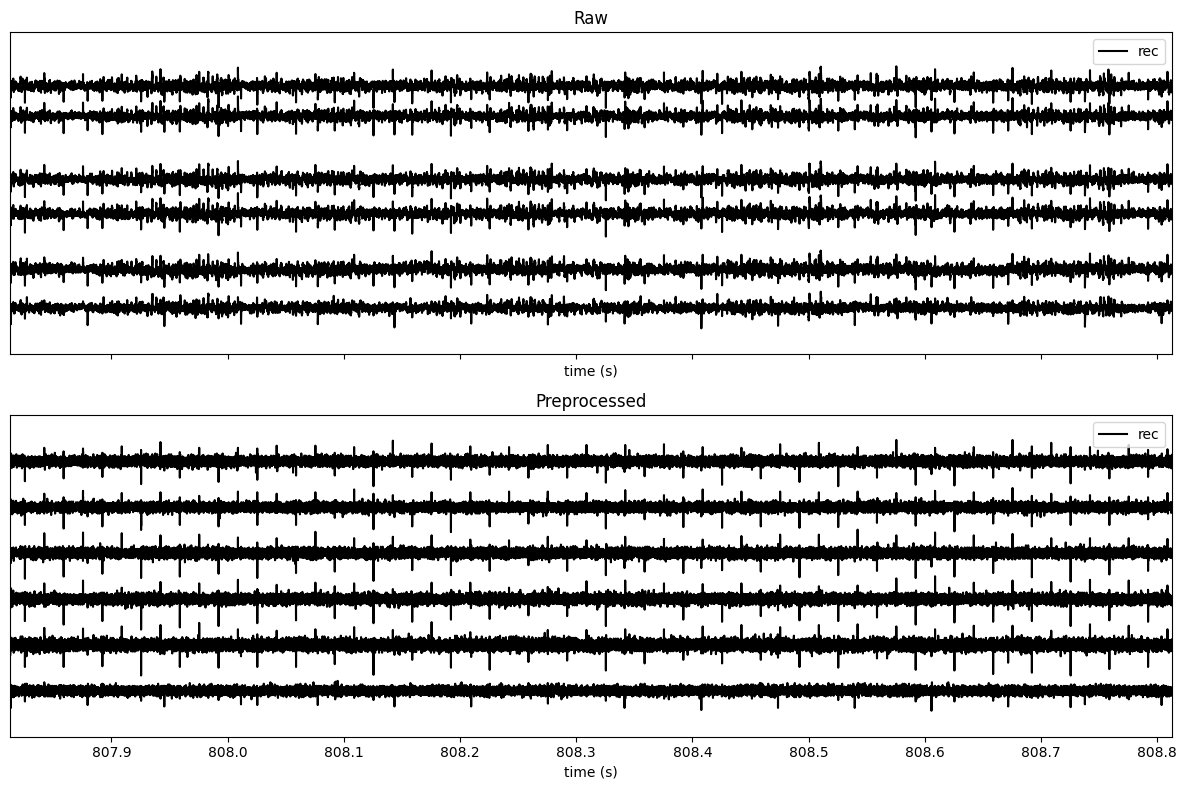

In [8]:
# TRACES VISUALIZATION
import re
_fs    = raw_rec.get_sampling_frequency()
raw_2s = raw_rec.frame_slice(0, int(2 * _fs))
rec_2s = rec.frame_slice(0, int(2 * _fs))

_nat_key     = lambda s: [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', s)]
_good_ch_ids = [c for c in sorted(raw_rec.channel_ids, key=_nat_key) if c in set(rec.channel_ids)]

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
si.plot_traces(raw_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[0])
si.plot_traces(rec_2s, channel_ids=_good_ch_ids[:6], mode='line', backend='matplotlib', ax=axes[1])
axes[0].set_title('Raw')
axes[1].set_title('Preprocessed')
plt.tight_layout()
plt.show()

In [9]:
# SAVE PREPROCESSED RECORDING + SPIKE SORTING
import gc, shutil
try: del analyzer
except NameError: pass
try: del rec_analysis
except NameError: pass
try: del raw_rec
except NameError: pass
try: del rec1
except NameError: pass
try: del rec2
except NameError: pass
try: del rec3
except NameError: pass
gc.collect()

# Windows file-lock safety: reuse existing folder if readable, else save to a fresh one.
# Cache is always skipped when test_duration_s is set — any clip change would load stale data.
_pf = base_folder / 'preprocess'
_pf_loaded = False
if _pf.exists() and test_duration_s is None:
    try:
        rec = si.load(_pf)
        _pf_loaded = True
        print(f'Loaded existing preprocessed recording (delete {_pf} to force re-saving)')
    except Exception:
        _pf = base_folder / 'preprocess_new'
        shutil.rmtree(_pf, ignore_errors=True)
        print('Existing preprocess folder is locked/corrupt — saving to preprocess_new')
if not _pf_loaded:
    rec = rec.save(folder=_pf, format='binary',
                   overwrite=True, n_jobs=1, chunk_duration='1s', progress_bar=True)
    print(f'Preprocessed recording saved -> {_pf}')

sorting = si.run_sorter(sorter, rec, folder=base_folder / f'{sorter}_output',
                        remove_existing_folder=True, verbose=True)
print(sorting)

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=21.86 MiB - total_memory=21.86 MiB - chunk_duration=1.00s (999.99 ms)


write_binary_recording (no parallelization):   0%|          | 0/61 [00:00<?, ?it/s]

Preprocessed recording saved -> C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\standalone_output\preprocess


kilosort.run_kilosort:  
kilosort.run_kilosort: Computing preprocessing variables.
kilosort.run_kilosort: ----------------------------------------
kilosort.run_kilosort: N samples: 1800000
kilosort.run_kilosort: N seconds: 59.99916975948848
kilosort.run_kilosort: N batches: 30
kilosort.run_kilosort: Preprocessing filters computed in  1.63s; total  1.63s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after preprocessing
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    33.50 %
kilosort.run_kilosort: Mem used:     42.70 %     |      13.53 GB
kilosort.run_kilosort: Mem avail:    18.18 / 31.71 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    N/A
kilosort.run_kilosort: GPU memory:   N/A
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort:  
kilosort.run_kilosort: Computing drift correction.
k

kilosort4 run time 2793.07s
KiloSortSortingExtractor: 144 units - 1 segments - 30.0kHz


In [10]:
# SORTING ANALYZER
si.set_global_job_kwargs(n_jobs=1, chunk_duration='1s', progress_bar=True)

rec_analysis = si.load(_pf)

analyzer = si.create_sorting_analyzer(sorting, rec_analysis,
                                       sparse=_analyzer_sparse, format='memory')
analyzer.compute('random_spikes', method='uniform', max_spikes_per_unit=max_spikes_per_unit)
analyzer.compute('waveforms', ms_before=waveform_ms_before, ms_after=waveform_ms_after)
analyzer.compute('templates', operators=['average', 'median', 'std'])
analyzer.compute('noise_levels')
analyzer.compute('correlograms')
analyzer.compute('unit_locations')
analyzer.compute('spike_amplitudes')
analyzer.compute('template_similarity')
print(analyzer)

estimate_sparsity (no parallelization):   0%|          | 0/61 [00:00<?, ?it/s]

compute_waveforms (no parallelization):   0%|          | 0/61 [00:00<?, ?it/s]

noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

spike_amplitudes (no parallelization):   0%|          | 0/61 [00:00<?, ?it/s]

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\postprocessing\template_similarity.py:345: NumbaTypeSafetyWarning: unsafe cast from uint64 to int64. Precision may be lost.
  overlapping_ids = overlapping_j_list[i]


SortingAnalyzer: 382 channels - 144 units - 1 segments - memory - sparse - has recording
Loaded 8 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity


In [11]:
# QUALITY METRICS
metrics_ext = analyzer.compute('quality_metrics', metric_names=metric_names)
metrics     = metrics_ext.get_data()
print(metrics)
metrics.to_csv(base_folder / 'quality_metrics.csv')
print(f"Quality metrics saved -> {base_folder / 'quality_metrics.csv'}")

     firing_rate  presence_ratio        snr  isi_violations_ratio  \
0       0.966667             1.0   6.546519             29.726501   
1       3.916669             1.0   8.259058             22.815742   
2      14.116674             1.0  13.489796              0.278781   
3      14.666674             1.0  11.691155              0.025826   
4      24.283346             1.0   2.469963              0.094213   
..           ...             ...        ...                   ...   
139     5.566669             1.0   2.043908              1.972103   
140     0.050000             1.0  13.489795              0.000000   
141     2.766668             1.0   3.703081              8.709533   
142     0.783334             1.0   8.993197             18.107732   
143    14.633341             1.0   7.056201              0.025944   

     isi_violations_count  amplitude_cutoff  
0                       5               NaN  
1                      63               NaN  
2                      10        

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\metrics\quality\misc_metrics.py:1026: UserWarning: Amplitude cutoff set to NaN for units [0, 1, 6, 7, 14, 17, 20, 21, 23, 24, 28, 29, 30, 31, 32, 34, 35, 36, 37, 38, 39, 41, 42, 43, 45, 46, 53, 57, 69, 72, 73, 77, 78, 79, 80, 82, 83, 84, 88, 90, 94, 95, 96, 97, 99, 101, 103, 107, 108, 110, 111, 112, 117, 120, 123, 127, 128, 129, 130, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142]: too few spikes (< 500).
  warnings.warn(


In [12]:
# QUALITY-BASED FILTERING
_conditions = []
if not metrics['amplitude_cutoff'].isna().all():
    _conditions.append(f"(amplitude_cutoff < {amplitude_cutoff_thresh})")
_conditions.append(f"(isi_violations_ratio < {isi_violations_ratio_thresh})")
if not metrics['presence_ratio'].isna().all():
    _conditions.append(f"(presence_ratio > {presence_ratio_thresh})")
query = " & ".join(_conditions)

keep_unit_ids = metrics.query(query).index.values
print(f"Keeping {len(keep_unit_ids)} / {len(sorting.unit_ids)} units after quality filtering")
if metrics['amplitude_cutoff'].isna().all():
    print("Note: amplitude_cutoff skipped (all NaN — too few spikes per unit)")
if metrics['presence_ratio'].isna().all():
    print("Note: presence_ratio skipped (all NaN — recording shorter than 60 s bin)")

analyzer = analyzer.select_units(keep_unit_ids)

Keeping 65 / 144 units after quality filtering


In [13]:
# EXPORT FINAL SPIKE TIMES
_spike_times_folder = base_folder / 'spike_times'
_spike_times_folder.mkdir(exist_ok=True)

_fs_export = rec_analysis.get_sampling_frequency()
for uid in keep_unit_ids:
    _train   = sorting.get_unit_spike_train(uid, segment_index=0)
    _times_s = _train / _fs_export
    np.savetxt(
        _spike_times_folder / f'unit_{uid}.csv',
        _times_s,
        delimiter=',', header='time_s', comments='', fmt='%.6f'
    )
print(f'Spike times for {len(keep_unit_ids)} units -> {_spike_times_folder}')

Spike times for 65 units -> C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\standalone_output\spike_times


In [14]:
# PIPELINE LOG
import json as _json, datetime as _dt

_log = {
    'timestamp':       _dt.datetime.now().isoformat(),
    'si_version':      si.__version__,
    'format':          FORMAT,
    'source_path':     _source_path,
    'sorter':          sorter,
    'n_channels_raw':  int(_n_raw_channels),
    'n_channels_kept': int(rec_analysis.get_num_channels()),
    'bad_channel_ids': [str(c) for c in bad_channel_ids],
    'n_units_sorted':  int(len(sorting.unit_ids)),
    'n_units_kept':    int(len(keep_unit_ids)),
    'parameters': {
        'freq_min':                    freq_min,
        'cref_operator':               cref_operator,
        'cref_reference':              cref_reference,
        'waveform_ms_before':          waveform_ms_before,
        'waveform_ms_after':           waveform_ms_after,
        'max_spikes_per_unit':         max_spikes_per_unit,
        'amplitude_cutoff_thresh':     amplitude_cutoff_thresh,
        'isi_violations_ratio_thresh': isi_violations_ratio_thresh,
        'presence_ratio_thresh':       presence_ratio_thresh,
    },
}
_log_path = base_folder / 'pipeline_run_log.json'
_log_path.write_text(_json.dumps(_log, indent=2))
print(f'Run log -> {_log_path}')

Run log -> C:\Users\labuser\Ilaria\data_for_Ilaria\2977_20250510\2977_20250510_g0\2977_20250510_g0_imec0\standalone_output\pipeline_run_log.json


In [15]:
# SAVE ANALYZER
import shutil
_analyzer_folder = base_folder / 'analyzer'
if _analyzer_folder.exists():
    shutil.rmtree(_analyzer_folder)
analyzer.save_as(folder=_analyzer_folder, format='binary_folder')

C:\Users\labuser\miniforge3\envs\si_pipeline\lib\site-packages\spikeinterface\core\basesorting.py:384: UserWarning: The registered recording will not be persistent on disk, but only available in memory
  warnings.warn("The registered recording will not be persistent on disk, but only available in memory")


SortingAnalyzer: 382 channels - 65 units - 1 segments - binary_folder - sparse - has recording
Loaded 9 extensions: random_spikes, waveforms, templates, noise_levels, correlograms, unit_locations, spike_amplitudes, template_similarity, quality_metrics

In [16]:
# INTERACTIVE VIEWER (sigui)
# Shows waveforms, ISI, amplitudes, probe map — click any unit to inspect.
import spikeinterface_gui
spikeinterface_gui.run_mainwindow(analyzer)